<a href="https://colab.research.google.com/github/DwiAyuniRohana/data-science-2025/blob/main/Pertemuan7_DwiAyuniRohana_250401020173.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Dwi Ayuni Rohana  
**NIM:** 250401020173  
**Prodi:** Informatika


--- EDA Singkat ---
Shape: (300, 4)

Statistik Deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22
--------------------------------------------------


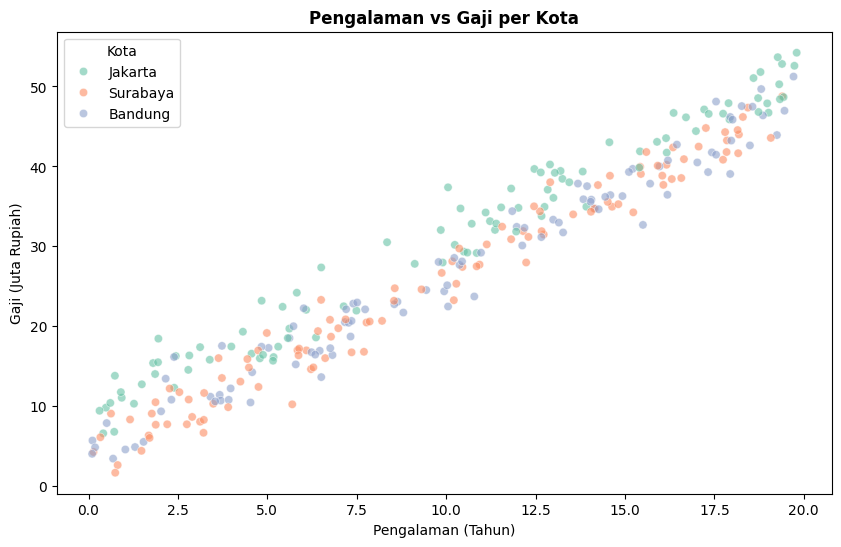

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Proteksi error scikit-learn versi terbaru
try:
    from sklearn.metrics import root_mean_squared_error
    has_new_rmse = True
except ImportError:
    has_new_rmse = False

# ------------------------------------------------------------------------------
# LANGKAH 1: Generate & Eksplorasi Dataset Sintetis
# ------------------------------------------------------------------------------
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# Menampilkan output ringkasan teks persis seperti di gambar
print('--- EDA Singkat ---')
print('Shape:', df.shape)
print('\nStatistik Deskriptif:')
print(df.describe().round(2))
print("-" * 50)

# Menampilkan grafik Scatter Plot awal yang kamu tanyakan
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota', fontsize=12, fontweight='bold')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')
plt.legend(title='Kota')
plt.show()


In [15]:
# ------------------------------------------------------------------------------
# LANGKAH 2: Preprocessing Data
# ------------------------------------------------------------------------------
# One-Hot Encoding kolom 'kota'
df_processed = pd.get_dummies(df, columns=['kota'], drop_first=True, dtype=int)

# Pisahkan fitur dan target
X = df_processed.drop('gaji', axis=1)
y = df_processed['gaji']

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [16]:
# ------------------------------------------------------------------------------
# LANGKAH 3: Latih Model & Tampilkan Koefisien
# ------------------------------------------------------------------------------
model = LinearRegression()
model.fit(X_train_s, y_train)


# ------------------------------------------------------------------------------
# LANGKAH 4: Evaluasi Model
# ------------------------------------------------------------------------------
y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

if has_new_rmse:
    rmse = root_mean_squared_error(y_test, y_pred)
else:
    rmse = mean_squared_error(y_test, y_pred, squared=False)

print('\n=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R² = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')
print("-" * 50)



=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R² = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474
--------------------------------------------------


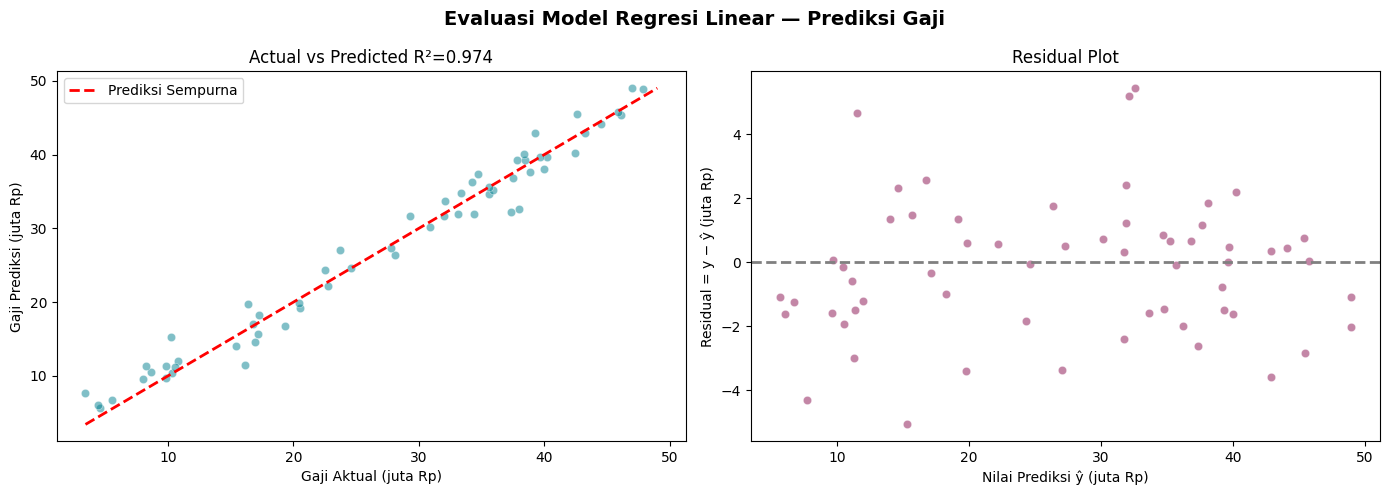

In [17]:


# ------------------------------------------------------------------------------
# LANGKAH 5: Visualisasi & Interpretasi Evaluasi
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5, color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')

plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()

# Menyimpan gambar plot otomatis ke file folder Colab
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

# Kesimpulan

Pada praktikum ini saya mempelajari tahapan lengkap (end-to-end) dalam membangun model Data Science untuk prediksi gaji menggunakan regresi linear. Proses yang dilakukan meliputi pembuatan dataset sintetis, eksplorasi data (EDA), preprocessing data menggunakan One-Hot Encoding dan StandardScaler, pembagian data training dan testing, pelatihan model Linear Regression, serta evaluasi performa model menggunakan metrik MAE, RMSE, dan R².

Hasil analisis menunjukkan bahwa variabel pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja memiliki pengaruh terhadap besarnya gaji. Visualisasi scatter plot memperlihatkan hubungan positif antara pengalaman kerja dan gaji, sedangkan hasil evaluasi model menunjukkan bahwa model mampu memprediksi gaji dengan tingkat akurasi yang cukup baik berdasarkan nilai R² yang diperoleh.

Keterbatasan dari praktikum ini adalah penggunaan dataset sintetis yang dibuat secara simulasi sehingga belum sepenuhnya merepresentasikan kondisi dunia nyata. Selain itu, model yang digunakan masih berupa regresi linear sederhana sehingga mungkin belum mampu menangkap hubungan yang lebih kompleks antar variabel. Untuk pengembangan selanjutnya, dapat dicoba menggunakan dataset riil dan membandingkan performa dengan algoritma machine learning lainnya seperti Random Forest atau Gradient Boosting.